In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt

# Warehouse Environment

In [ ]:


class WarehouseEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self):
        super().__init__()

        # Grid size
        self.grid_size = 5

        # Action & Observation spaces
        self.action_space = spaces.Discrete(6)
        self.observation_space = spaces.Discrete(500)

        # Fixed pickup / delivery locations
        self.locations = {
            0: (0, 0),   # Dock A
            1: (0, 4),   # Dock B
            2: (4, 0),   # Dock C
            3: (4, 3),   # Dock D
        }

        # Each entry blocks movement from (row, col) in a direction
        # Directions: "N", "S", "E", "W"
        self.walls = {
            (0, 1, "E"), (0, 2, "W"),
            (1, 1, "E"), (1, 2, "W"),
            (2, 3, "E"), (2, 4, "W"),
            (3, 0, "E"), (3, 1, "W"),
        }

        self.reset()

    # ---------- STATE ENCODING ----------
    def encode(self, row, col, pkg_loc, dest):
        return ((row * 5 + col) * 5 + pkg_loc) * 4 + dest

    def decode(self, state):
        dest = state % 4
        state //= 4
        pkg_loc = state % 5
        state //= 5
        col = state % 5
        row = state // 5
        return row, col, pkg_loc, dest

    # ---------- RESET ----------
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.robot_row = np.random.randint(5)
        self.robot_col = np.random.randint(5)

        self.pkg_loc = np.random.choice([0, 1, 2, 3])
        self.dest = np.random.choice([d for d in range(4) if d != self.pkg_loc])

        state = self.encode(
            self.robot_row, self.robot_col, self.pkg_loc, self.dest
        )

        return state, {}

    # ---------- STEP ----------
    def step(self, action):
        reward = -1
        terminated = False

        r, c = self.robot_row, self.robot_col

        # ----- MOVEMENT WITH WALL CHECKS -----
        if action == 0:  # South
            if r < 4 and (r, c, "S") not in self.walls:
                self.robot_row += 1

        elif action == 1:  # North
            if r > 0 and (r, c, "N") not in self.walls:
                self.robot_row -= 1

        elif action == 2:  # East
            if c < 4 and (r, c, "E") not in self.walls:
                self.robot_col += 1

        elif action == 3:  # West
            if c > 0 and (r, c, "W") not in self.walls:
                self.robot_col -= 1

        # ----- PICKUP -----
        elif action == 4:
            if self.pkg_loc < 4:
                if (self.robot_row, self.robot_col) == self.locations[self.pkg_loc]:
                    self.pkg_loc = 4  # package now inside robot
                else:
                    reward = -10
            else:
                reward = -10

        # ----- DROPOFF -----
        elif action == 5:
            if self.pkg_loc == 4:
                if (self.robot_row, self.robot_col) == self.locations[self.dest]:
                    reward = 20
                    terminated = True
                else:
                    reward = -10
            else:
                reward = -10

        state = self.encode(
            self.robot_row, self.robot_col, self.pkg_loc, self.dest
        )

        return state, reward, terminated, False, {}

    # ---------- RENDER ----------
    def render(self):
        grid = [["." for _ in range(5)] for _ in range(5)]

        # Locations
        for k, (r, c) in self.locations.items():
            grid[r][c] = str(k)

        # Robot
        if self.pkg_loc == 4:
            grid[self.robot_row][self.robot_col] = "R*"
        else:
            grid[self.robot_row][self.robot_col] = "R"

        print("\n".join(" ".join(row) for row in grid))
        print(f"Package: {self.pkg_loc}, Destination: {self.dest}")
        print("-" * 30)


#### Basic render of environment

In [ ]:
env = WarehouseEnv()
env.render()

0 . . . 1
. . . . .
. . . . .
. . . . .
R . . 3 .
Package: 0, Destination: 2
------------------------------


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random


# DQN

In [ ]:


env = WarehouseEnv()


class DQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(500, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = torch.nn.functional.one_hot(x, num_classes=500).float()
        return self.net(x)


policy_net = DQN()
target_net = DQN()
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
memory = deque(maxlen=50_000)

gamma = 0.99
batch_size = 64
epsilon = 1.0
epsilon_decay = 0.997
epsilon_min = 0.05
# rewards_log = []
# epsilon_log = []
# success_log = []



def select_action(state):
    global epsilon
    if random.random() < epsilon:
        return env.action_space.sample()
    with torch.no_grad():
        s = torch.tensor([state])
        return torch.argmax(policy_net(s)).item()

def train_step():
    if len(memory) < batch_size:
        return

    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.tensor(states)
    actions = torch.tensor(actions)
    rewards = torch.tensor(rewards, dtype=torch.float32)
    next_states = torch.tensor(next_states)
    dones = torch.tensor(dones, dtype=torch.float32)

    q_vals = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze()
    next_q = target_net(next_states).max(1)[0]
    target = rewards + gamma * next_q * (1 - dones)

    loss = nn.MSELoss()(q_vals, target)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
    optimizer.step()


# Training

In [ ]:
episodes = 2000
rewards_log = []
epsilon_log = []
success_log = []

for ep in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    for t in range(200):
        action = select_action(state)
        next_state, reward, done, _, _ = env.step(action)

        memory.append((state, action, reward, next_state, done))
        train_step()

        state = next_state
        total_reward += reward

        if done:
            break


    if not done:
        memory.append((state, action, -20, state, True))

    rewards_log.append(total_reward)
    epsilon_log.append(epsilon)
    success_log.append(1 if done else 0)

    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    if ep % 10 == 0:
        target_net.load_state_dict(policy_net.state_dict())
        print(f"Episode {ep}, Reward {total_reward}, Epsilon {epsilon:.3f}")


Episode 0, Reward -722, Epsilon 0.997
Episode 10, Reward -717, Epsilon 0.967
Episode 20, Reward -704, Epsilon 0.939
Episode 30, Reward -767, Epsilon 0.911
Episode 40, Reward -785, Epsilon 0.884
Episode 50, Reward -369, Epsilon 0.858
Episode 60, Reward -731, Epsilon 0.833
Episode 70, Reward -261, Epsilon 0.808
Episode 80, Reward -117, Epsilon 0.784
Episode 90, Reward -80, Epsilon 0.761
Episode 100, Reward -249, Epsilon 0.738
Episode 110, Reward -255, Epsilon 0.716
Episode 120, Reward -650, Epsilon 0.695
Episode 130, Reward -587, Epsilon 0.675
Episode 140, Reward -359, Epsilon 0.655
Episode 150, Reward -36, Epsilon 0.635
Episode 160, Reward -136, Epsilon 0.616
Episode 170, Reward 4, Epsilon 0.598
Episode 180, Reward -193, Epsilon 0.581
Episode 190, Reward -9, Epsilon 0.563
Episode 200, Reward -35, Epsilon 0.547
Episode 210, Reward -88, Epsilon 0.530
Episode 220, Reward -43, Epsilon 0.515
Episode 230, Reward -128, Epsilon 0.500
Episode 240, Reward -11, Epsilon 0.485
Episode 250, Reward -3

# Plots

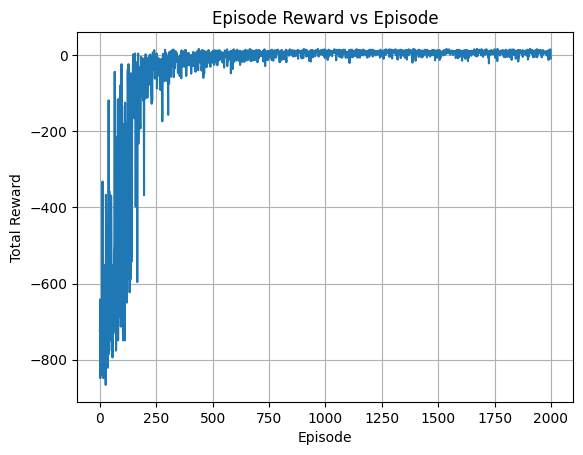

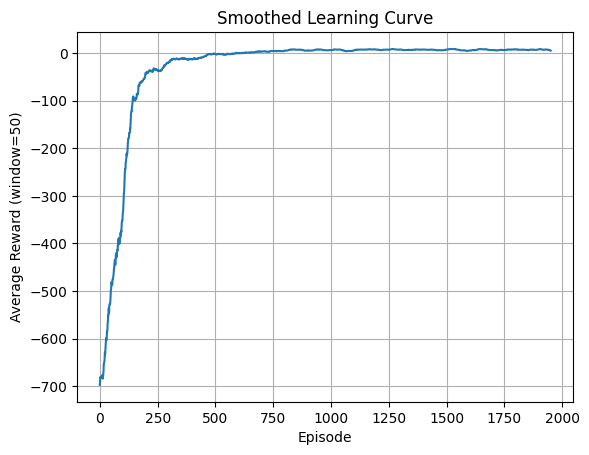

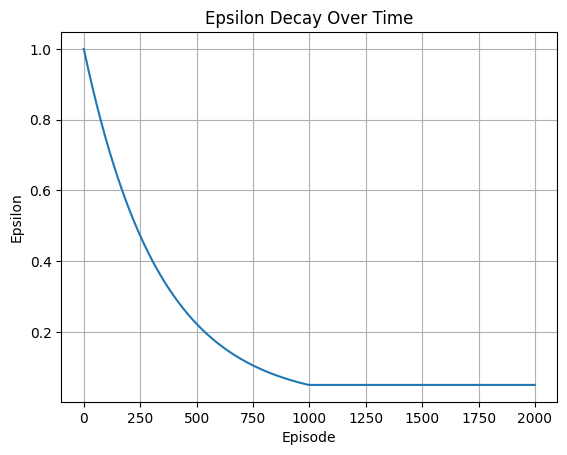

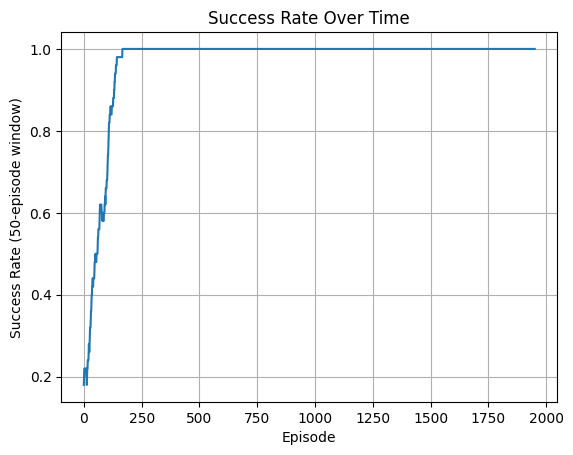

In [ ]:


rewards = np.array(rewards_log)

# ---- Episode Reward ----
plt.figure()
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Episode Reward vs Episode")
plt.grid(True)
plt.show()

# ---- Moving Average ----
window = 50
moving_avg = np.convolve(rewards, np.ones(window) / window, mode="valid")

plt.figure()
plt.plot(moving_avg)
plt.xlabel("Episode")
plt.ylabel(f"Average Reward (window={window})")
plt.title("Smoothed Learning Curve")
plt.grid(True)
plt.show()

# ---- Epsilon Decay ----
plt.figure()
plt.plot(epsilon_log)
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay Over Time")
plt.grid(True)
plt.show()

# ---- Success Rate ----
success_rate = np.convolve(success_log, np.ones(50) / 50, mode="valid")

plt.figure()
plt.plot(success_rate)
plt.xlabel("Episode")
plt.ylabel("Success Rate (50-episode window)")
plt.title("Success Rate Over Time")
plt.grid(True)
plt.show()


#### Code for animation

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import imageio
import torch
import numpy as np


def save_side_by_side_mp4(env_class, policy_net, filename="warehouse_random_vs_trained.mp4"):
    writer = imageio.get_writer(filename, fps=2)

    # Two environments with identical initial states
    env_random = env_class()
    env_trained = env_class()

    state, _ = env_random.reset()
    env_trained.robot_row = env_random.robot_row
    env_trained.robot_col = env_random.robot_col
    env_trained.pkg_loc = env_random.pkg_loc
    env_trained.dest = env_random.dest

    state_trained = state
    done_random = False
    done_trained = False

    for step in range(200):
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        for ax, env, title in zip(
            axes,
            [env_random, env_trained],
            ["Random Policy", "Trained DQN"]
        ):
            ax.set_xlim(0, 5)
            ax.set_ylim(0, 5)
            ax.set_xticks(range(6))
            ax.set_yticks(range(6))
            ax.grid(True)
            ax.set_aspect("equal")
            ax.set_title(title)

            # ---- Walls ----
            for (r, c, d) in env.walls:
                if d == "E":
                    ax.plot([c+1, c+1], [4-r, 5-r], 'k', lw=3)
                elif d == "W":
                    ax.plot([c, c], [4-r, 5-r], 'k', lw=3)

            # ---- Locations (draw all docks) ----
            for i, (r, c) in env.locations.items():
                ax.text(
                    c + 0.5,
                    4.5 - r,
                    f"D{i}",
                    ha="center",
                    va="center",
                    fontsize=12,
                    fontweight="bold",
                    color="black"
                )

            # ---- Delivery location (highlight) ----
            dr, dc = env.locations[env.dest]
            delivery_box = patches.Rectangle(
                (dc + 0.05, 4.05 - dr),
                0.9,
                0.9,
                fill=False,
                edgecolor="red",
                linewidth=3
            )
            ax.add_patch(delivery_box)


            # ---- Robot ----
            color = "orange" if env.pkg_loc == 4 else "blue"
            robot = patches.Circle(
                (env.robot_col+0.5, 4.5-env.robot_row),
                0.3,
                color=color
            )
            ax.add_patch(robot)

            # ---- Package ----
            if env.pkg_loc < 4:
                pr, pc = env.locations[env.pkg_loc]
                pkg = patches.Rectangle(
                    (pc+0.2, 4.2-pr),
                    0.6, 0.6,
                    color="green"
                )
                ax.add_patch(pkg)

        # ---- Capture frame (FIXED) ----
        fig.canvas.draw()
        frame = np.asarray(fig.canvas.buffer_rgba())
        frame = frame[:, :, :3]  # remove alpha channel
        writer.append_data(frame)
        plt.close(fig)

        # ---- Random agent step ----
        if not done_random:
            a_r = env_random.action_space.sample()
            _, _, done_random, _, _ = env_random.step(a_r)

        # ---- Trained agent step ----
        if not done_trained:
            with torch.no_grad():
                a_t = torch.argmax(policy_net(torch.tensor([state_trained]))).item()
            state_trained, _, done_trained, _, _ = env_trained.step(a_t)

        if done_random and done_trained:
            break

    writer.close()
    print(f"✅ MP4 saved as {filename}")


#### Saving Animation

In [ ]:
save_side_by_side_mp4(WarehouseEnv, policy_net)


✅ MP4 saved as warehouse_random_vs_trained.mp4


#### Downloading Animation

In [ ]:
from google.colab import files
files.download("warehouse_random_vs_trained.mp4")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>